In [0]:
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql.window import Window
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pyspark.sql.functions as F

In [0]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv" 
df = pd.read_csv(url) 
df = df.rename(columns={ "bill_length_mm": "culmen_length_mm", "bill_depth_mm": "culmen_depth_mm" })

In [0]:
df.shape

(344, 8)

In [0]:
df.head().display()

species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
Adelie,Torgersen,null,null,null,null,null,2007
Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


1. ¿Qué columnas tiene? ¿Cuál sería el target? ¿Hay valores nulos, clases desbalanceadas o problemas que debamos considerer?

In [0]:
df_sp = spark.createDataFrame(df)

In [0]:
df_sp.printSchema()

root
 |-- species: string (nullable = true)
 |-- island: string (nullable = true)
 |-- culmen_length_mm: double (nullable = true)
 |-- culmen_depth_mm: double (nullable = true)
 |-- flipper_length_mm: double (nullable = true)
 |-- body_mass_g: double (nullable = true)
 |-- sex: string (nullable = true)
 |-- year: long (nullable = true)



In [0]:
#verificar nulos
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [0]:
df_sp.groupBy("species").count().display()

species,count
Adelie,152
Gentoo,124
Chinstrap,68


Databricks visualization. Run in Databricks to view.

In [0]:
df_sp.groupBy("island").count().display()

island,count
Torgersen,52
Biscoe,168
Dream,124


Databricks visualization. Run in Databricks to view.

In [0]:
df_sp.groupBy("species","island").count().display()

species,island,count
Adelie,Torgersen,52
Adelie,Biscoe,44
Adelie,Dream,56
Gentoo,Biscoe,124
Chinstrap,Dream,68


Databricks visualization. Run in Databricks to view.

2. Queremos entender si las especies de pingüinos se pueden distinguir usando sus medidas físicas.
¿Qué variables parecen separar mejor las especies? Justifica con tablas o gráficos simples.

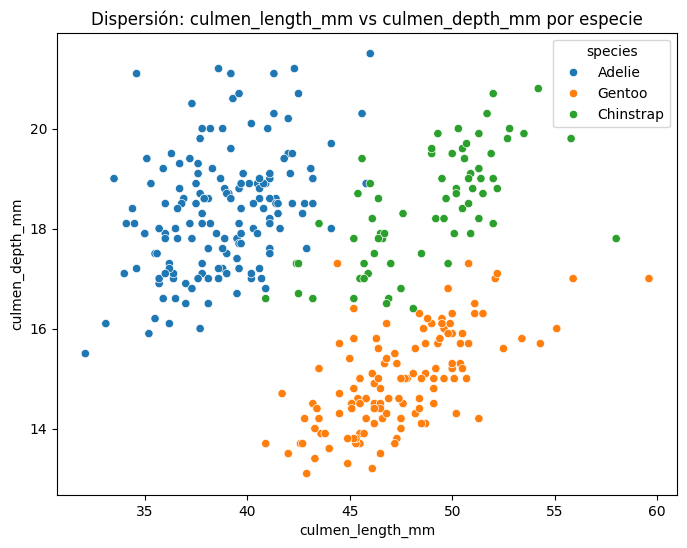

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="culmen_length_mm", y="culmen_depth_mm", hue="species")
plt.title("Dispersión: culmen_length_mm vs culmen_depth_mm por especie")
plt.xlabel("culmen_length_mm")
plt.ylabel("culmen_depth_mm")
plt.legend(title="species")
plt.show()

3. Construye un modelo simple para predecir species usando las variables físicas.
Explica cómo manejas los nulos, cómo separas train/test y qué métrica usarías para evaluar el modelo.

In [0]:
df_sp.describe().display()

summary,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,year
count,344,344,342,342,342,342,333,344
mean,null,null,43.92192982456141,17.151169590643274,200.91520467836258,4201.754385964912,null,2008.0290697674418
stddev,null,null,5.459583713926528,1.9747931568167814,14.061713679356888,801.9545356980955,null,0.8183559254837114
min,Adelie,Biscoe,32.1,13.1,172.0,2700.0,female,2007
max,Gentoo,Torgersen,59.6,21.5,231.0,6300.0,male,2009


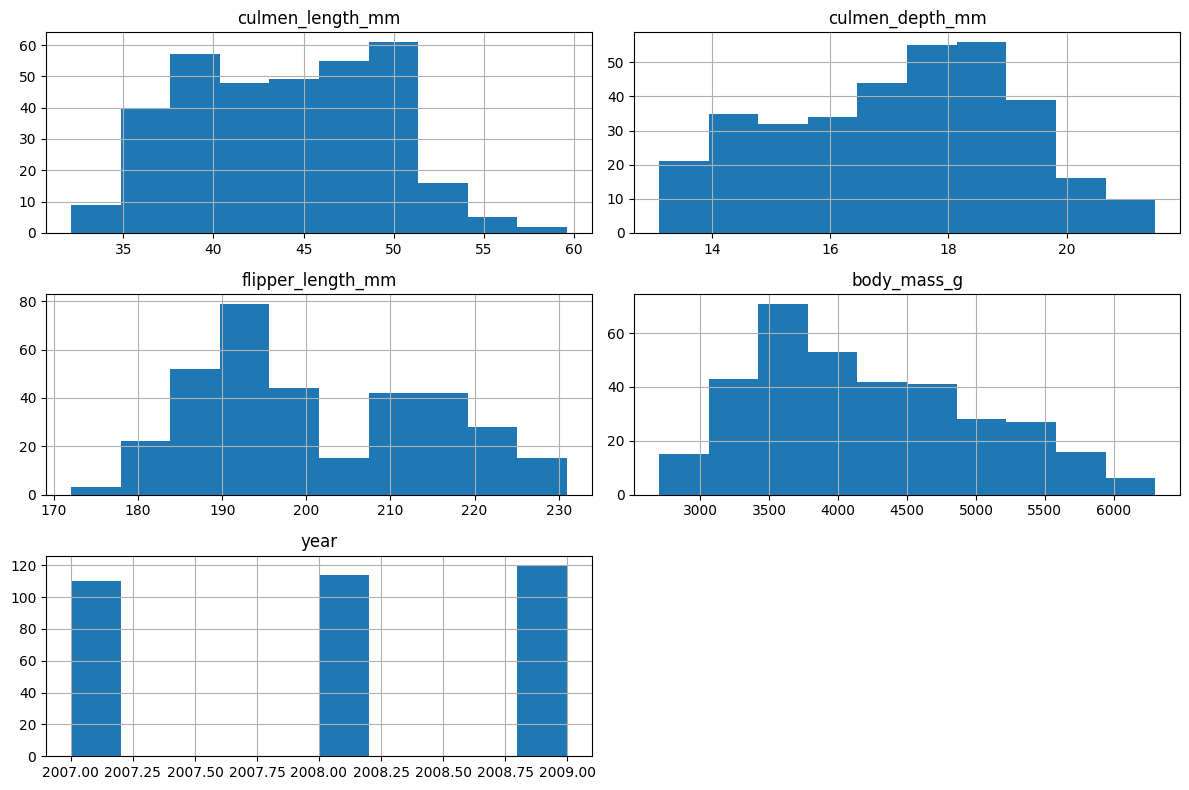

In [0]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

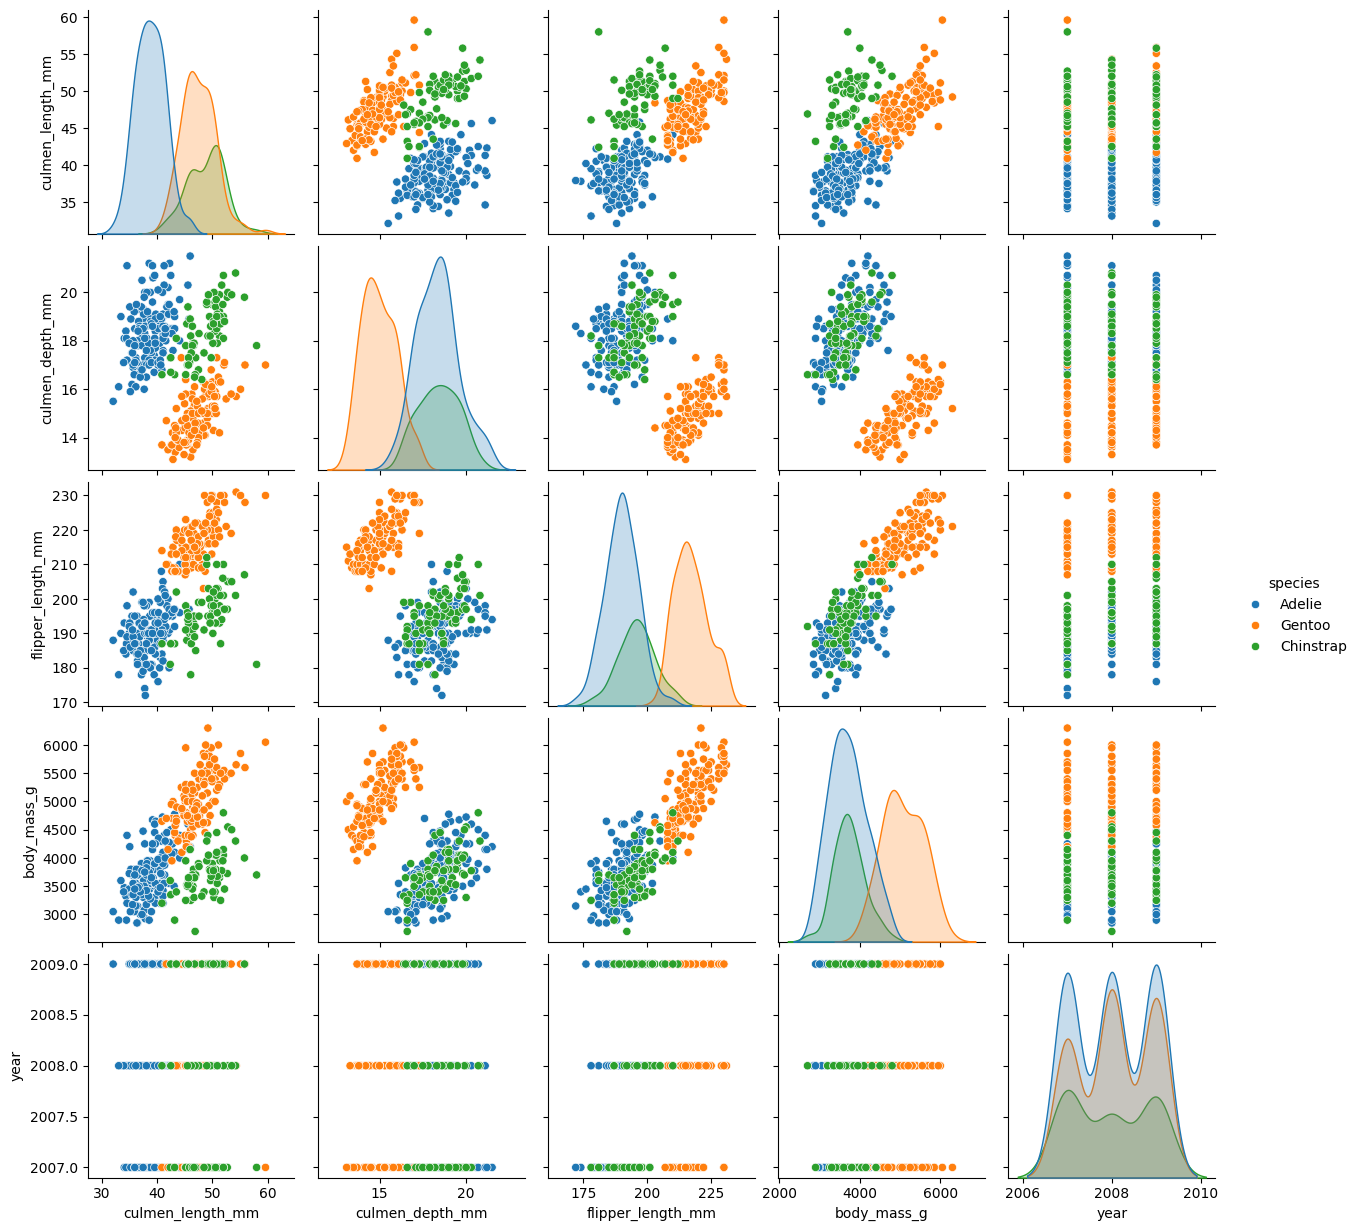

In [0]:
sns.pairplot(df, hue="species")
plt.show()

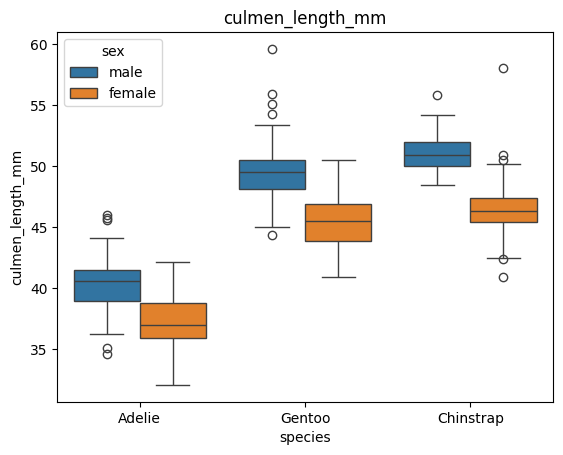

In [0]:
def box(f):
    sns.boxplot(y = f, x = 'species', hue = 'sex',data = df)
    plt.title(f)
    plt.show()

box('culmen_length_mm')

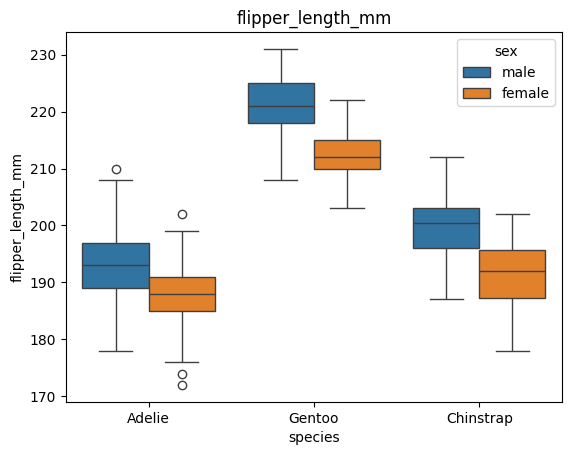

In [0]:
box('flipper_length_mm')

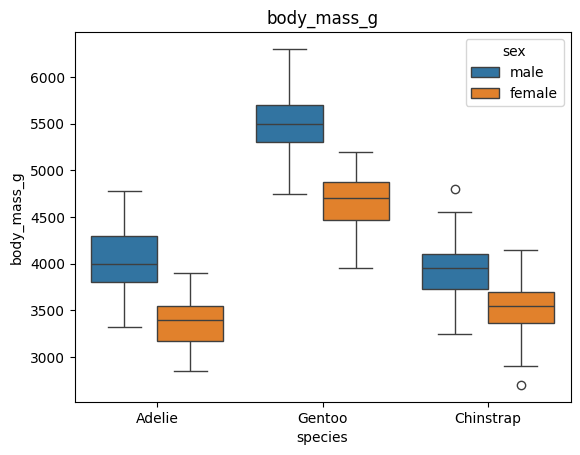

In [0]:
box('body_mass_g')

In [0]:
# Eliminar filas con nulos en las variables físicas
features = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
df_model = df_sp.dropna(subset=features + ["species"])

# Indexar la variable target
indexer_model = StringIndexer(inputCol="species", outputCol="label").fit(df_model)
df_model = indexer_model.transform(df_model)

# indexer_model.labels es una lista donde la posición i corresponde al label i
labels_map = indexer_model.labels

# Vectorizar las variables físicas
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_model = assembler.transform(df_model)

In [0]:
# Calcular class weights
label_counts = df_model.groupBy("label").count().toPandas()
total = label_counts["count"].sum()
weights = {row["label"]: total / (len(label_counts) * row["count"]) for _, row in label_counts.iterrows()}

df_model = df_model.withColumn(
    "classWeightCol",
    F.expr(
        "CASE " +
        " ".join([f"WHEN label = {int(label)} THEN {weight}" for label, weight in weights.items()]) +
        " ELSE 1 END"
    )
)

# Separar train/test
train, test = df_model.randomSplit([0.8, 0.2], seed=42)

# Entrenar Random Forest con class weights
rf = RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="classWeightCol", numTrees=100)
model = rf.fit(train)

In [0]:
predictions = model.transform(test)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Métricas globales
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1_weighted = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Métricas por clase, con el nombre real de la especie
metricas_clase = []
for i, especie in enumerate(labels_map):
    params = {evaluator.metricLabel: float(i)}
    metricas_clase.append({
        "Especie": especie,
        "Precisión": evaluator.evaluate(predictions, {evaluator.metricName: "precisionByLabel", **params}),
        "Recall": evaluator.evaluate(predictions, {evaluator.metricName: "recallByLabel", **params}),
        "F1-score": evaluator.evaluate(predictions, {evaluator.metricName: "fMeasureByLabel", **params}),
        "Soporte (test)": predictions.filter(F.col("label") == i).count()
    })

df_metricas = pd.DataFrame(metricas_clase)

print(f"Accuracy global : {accuracy:.4f}")
print(f"F1 ponderado    : {f1_weighted:.4f}\n")
print(df_metricas.round(4).to_string(index=False))

Accuracy global : 0.9861
F1 ponderado    : 0.9862

  Especie  Precisión  Recall  F1-score  Soporte (test)
   Adelie     1.0000  0.9643    0.9818              28
   Gentoo     1.0000  1.0000    1.0000              30
Chinstrap     0.9333  1.0000    0.9655              14


Tenemos una precisión perfecta en detectar las especies Gentoo y Chinstrap, sin embargo tenemos problemas en detectar la especie Adelie, el problema es que estamos detectando a un pinguino Adelie como Chinstrap de forma erronea, si agregamos la isla de donde son originarios podriamos mejorar aún más la métrica.

In [0]:

# Variables físicas
num_features = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

# Eliminar filas con nulos en las variables físicas, target e isla
df_model = df_sp.dropna(subset=num_features + ["species", "island"])

# Indexar la variable target
indexer_model = StringIndexer(inputCol="species", outputCol="label").fit(df_model)
df_model = indexer_model.transform(df_model)
labels_map = indexer_model.labels

# One-hot encoding de island: primero indexar, luego encodear
island_indexer = StringIndexer(inputCol="island", outputCol="island_idx").fit(df_model)
df_model = island_indexer.transform(df_model)

island_encoder = OneHotEncoder(inputCol="island_idx", outputCol="island_ohe").fit(df_model)
df_model = island_encoder.transform(df_model)

# Vectorizar variables físicas + isla codificada
assembler = VectorAssembler(
    inputCols=num_features + ["island_ohe"],
    outputCol="features"
)
df_model = assembler.transform(df_model)

In [0]:

# Calcular class weights
label_counts = df_model.groupBy("label").count().toPandas()
total = label_counts["count"].sum()
weights = {row["label"]: total / (len(label_counts) * row["count"]) for _, row in label_counts.iterrows()}

df_model = df_model.withColumn(
    "classWeightCol",
    F.expr(
        "CASE " +
        " ".join([f"WHEN label = {int(label)} THEN {weight}" for label, weight in weights.items()]) +
        " ELSE 1 END"
    )
)

# Separar train/test
train, test = df_model.randomSplit([0.8, 0.2], seed=42)

# Entrenar Random Forest con class weights
rf = RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="classWeightCol", numTrees=100)
model = rf.fit(train)

In [0]:
predictions = model.transform(test)

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Métricas globales
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1_weighted = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

# Métricas por clase, con el nombre real de la especie
metricas_clase = []
for i, especie in enumerate(labels_map):
    params = {evaluator.metricLabel: float(i)}
    metricas_clase.append({
        "Especie": especie,
        "Precisión": evaluator.evaluate(predictions, {evaluator.metricName: "precisionByLabel", **params}),
        "Recall": evaluator.evaluate(predictions, {evaluator.metricName: "recallByLabel", **params}),
        "F1-score": evaluator.evaluate(predictions, {evaluator.metricName: "fMeasureByLabel", **params}),
        "Soporte (test)": predictions.filter(F.col("label") == i).count()
    })

df_metricas = pd.DataFrame(metricas_clase)

print(f"Accuracy global : {accuracy:.4f}")
print(f"F1 ponderado    : {f1_weighted:.4f}\n")
print(df_metricas.round(4).to_string(index=False))

Accuracy global : 1.0000
F1 ponderado    : 1.0000

  Especie  Precisión  Recall  F1-score  Soporte (test)
   Adelie        1.0     1.0       1.0              28
   Gentoo        1.0     1.0       1.0              30
Chinstrap        1.0     1.0       1.0              14


Perfecto, tenemos las métricas al máximo.

In [0]:
# Matriz de confusión con nombres reales
conf = (predictions
        .groupBy("label")
        .pivot("prediction")
        .count()
        .fillna(0)
        .toPandas()
        .sort_values("label"))

conf["label"] = conf["label"].apply(lambda i: labels_map[int(i)])
conf.columns = ["Real \\ Predicho"] + [labels_map[int(float(c))] for c in conf.columns[1:]]

print("\nMatriz de confusión:")
print(conf.to_string(index=False))


Matriz de confusión:
Real \ Predicho  Adelie  Gentoo  Chinstrap
         Adelie      28       0          0
         Gentoo       0      30          0
      Chinstrap       0       0         14
